# **Project Type**    - Classification
# **Contribution**    - Individual

# **Project Summary**

Customer satisfaction is a critical success factor in the e-commerce industry, directly influencing customer retention, brand loyalty, and business growth. This project focuses on analyzing customer service interactions at Flipkart to understand the factors that impact Customer Satisfaction (CSAT) scores and to develop a predictive model that can forecast customer satisfaction levels.

The dataset contains information related to customer support interactions, including issue categories, support channels, agent details, handling times, and customer feedback scores. The project began with a thorough data cleaning process, where missing values, duplicate records, and irrelevant attributes were identified and handled appropriately. Date and time variables were converted into suitable formats to facilitate analysis.

Exploratory Data Analysis (EDA) was performed to uncover patterns and relationships within the data. Various visualizations were used to examine the distribution of CSAT scores and analyze the influence of factors such as support channels, issue types, product categories, and agent performance on customer satisfaction. These insights helped identify key trends affecting customer experience.

Feature engineering techniques were applied to create new variables, including issue resolution time and order-to-issue reporting delays, which provided additional business-relevant information. The data was then preprocessed using missing value imputation and categorical variable encoding to prepare it for machine learning.

A Random Forest Classifier was developed to predict CSAT scores based on customer interaction and service-related features. The model was evaluated using metrics such as accuracy, precision, recall, F1-score, and confusion matrix to assess its predictive performance.

To improve interpretability, feature importance analysis and SHAP (SHapley Additive Explanations) were used to identify the most influential factors affecting customer satisfaction. The results highlighted the importance of service efficiency, resolution time, and support quality in determining CSAT scores.

The project provides actionable recommendations for Flipkart to optimize customer service operations, improve customer experience, and enhance overall satisfaction, ultimately contributing to stronger customer loyalty and long-term business success.

# **GitHub Link -**

# **Problem Statement**

In the highly competitive e-commerce space, delivering excellent customer service is crucial for sustaining growth and customer loyalty. Flipkart, as one of the largest e-commerce platforms, focuses on enhancing customer satisfaction to differentiate itself from competitors. The dataset in this project captures customer interactions, feedback, and satisfaction scores across various support channels at Flipkart. By analyzing these interactions, the goal is to identify key drivers of customer satisfaction, understand performance across different customer service teams, and develop strategies to improve the overall service experience. Understanding factors that influence customer satisfaction will allow Flipkart to not only resolve customer issues faster but also tailor its support strategies to meet diverse customer expectations. This will help in optimizing the performance of service agents and improving satisfaction metrics like the CSAT score, ultimately leading to increased brand loyalty and customer retention.

#**1. KNOW YOUR DATA**

In [2]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [206]:
# Load Data
try:
    #df = pd.read_csv("flipkart_csat.csv")
    df = pd.read_csv('/content/Customer_support_data.csv')

    print("Dataset Loaded Successfully")
    print(f"Dataset Shape : {df.shape}")

except FileNotFoundError:
    print("Error: Dataset file not found.")

except Exception as e:
    print("Error:", e)

Dataset Loaded Successfully
Dataset Shape : (85907, 20)


In [207]:
# Display first 5 records of the dataset
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [208]:
# Display last 5 records of the dataset
df.tail()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


In [209]:
# Dataset Dimensions

rows = df.shape[0]
cols = df.shape[1]

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 85907
Number of Columns : 20


In [210]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [211]:
# Data Description
# statistical summary of Numerical variables in the dataset
df.describe().T

# Provides:

# - Count
# - Mean
# - Standard Deviation
# - Minimum
# - Maximum
# - Quartiles

# Business Impact:

# Helps identify abnormal values,
# potential outliers and data distribution.


,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0


In [212]:
# Statistical summary of Categorical Variables in the dataset
df.describe(include='object').T

# Provides:

# - Count
# - Unique Categories
# - Most Frequent Category
# - Frequency

# Business Impact:

# Helps understand customer segmentation
# and dominant service categories.

,count,unique,top,freq
Unique id,85907,85907,07c7a878-0d5a-42e0-97ef-de59abec0238,1
channel_name,85907,3,Inbound,68142
category,85907,12,Returns,44097
Sub-category,85907,57,Reverse Pickup Enquiry,22389
Customer Remarks,28742,18231,Good,1390
Order_id,67675,67675,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1
order_date_time,17214,13766,09/08/2023 11:55,7
Issue_reported at,85907,30923,13/08/2023 10:40,13
issue_responded,85907,30262,28/08/2023 00:00,3378
Survey_response_Date,85907,31,28-Aug-23,3452


In [213]:
# Missing values Analysis

missing_values = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage':
        round((df.isnull().sum()/len(df))*100,2)
})

missing_values = missing_values.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


In [214]:
# Unique Values in Each Column
unique_df = pd.DataFrame({
    'Column': df.columns,
    'Unique Values':
    [df[col].nunique() for col in df.columns]
})

unique_df.sort_values(
    by='Unique Values',
    ascending=False
)

,Column,Unique Values
0,Unique id,85907
5,Order_id,67675
7,Issue_reported at,30923
8,issue_responded,30262
4,Customer Remarks,18231
6,order_date_time,13766
12,Item_price,2789
10,Customer_City,1782
14,Agent_name,1371
13,connected_handling_time,211


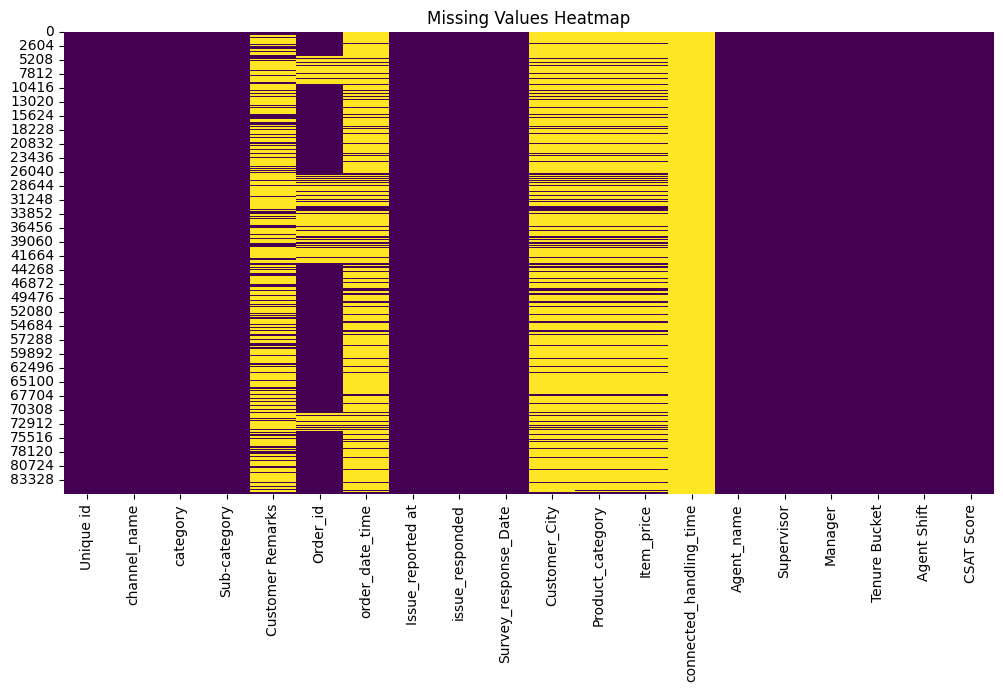

In [215]:
# Missing Value Visualisation

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

# Why Heatmap?

# Heatmaps visually identify patterns of missing data
# across columns and rows.

# Insight:

# Certain columns may contain significant missing values.

# Business Impact:

# Columns with excessive missing values may require
# special treatment before modeling.

In [216]:
# DUPLICATE RECORDS

duplicate_count = df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

# Duplicate records may introduce bias
# during model training.

# Business Impact:

# Removing duplicates improves data quality
# and prevents misleading insights.

Duplicate Records : 0


In [217]:
print("========== DATASET SUMMARY ==========")

print(f"Rows                : {df.shape[0]}")
print(f"Columns             : {df.shape[1]}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Records   : {df.duplicated().sum()}")

print("=====================================")


========== DATASET SUMMARY ==========
Rows                : 85907
Columns             : 20
Missing Values      : 435995
Duplicate Records   : 0


**Key Findings:**

1. Dataset contains customer support interactions.
2. Several columns contain missing values.
3. Both numerical and categorical variables exist.
4. Target variable is CSAT Score.
5. Data cleaning is required before modeling.

#***UNDERSTANDING THE VARIABLES***

In [218]:
# DISPLAY ALL VARIABLES

print("List of Variables:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

List of Variables:

1. Unique id
2. channel_name
3. category
4. Sub-category
5. Customer Remarks
6. Order_id
7. order_date_time
8. Issue_reported at
9. issue_responded
10. Survey_response_Date
11. Customer_City
12. Product_category
13. Item_price
14. connected_handling_time
15. Agent_name
16. Supervisor
17. Manager
18. Tenure Bucket
19. Agent Shift
20. CSAT Score


In [219]:
# VARIABLE SUMMARY

variable_summary = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

variable_summary

,Column Name,Data Type,Missing Values,Unique Values
0,Unique id,object,0,85907
1,channel_name,object,0,3
2,category,object,0,12
3,Sub-category,object,0,57
4,Customer Remarks,object,57165,18231
5,Order_id,object,18232,67675
6,order_date_time,object,68693,13766
7,Issue_reported at,object,0,30923
8,issue_responded,object,0,30262
9,Survey_response_Date,object,0,31


In [220]:
# NUMERICAL VARIABLES

numerical_columns = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

print("Numerical Variables:\n")

for col in numerical_columns:
    print(col)

print("\nTotal Numerical Variables :", len(numerical_columns))

# Numerical variables contain measurable quantities.

# - Item Price
# - CSAT Score
# - Handling Time

# These variables will be used for:
# 1. Statistical analysis
# 2. Correlation analysis
# 3. Machine Learning

Numerical Variables:

Item_price
connected_handling_time
CSAT Score

Total Numerical Variables : 3


In [221]:
# CATEGORICAL VARIABLES
categorical_columns = df.select_dtypes(
    include='object'
).columns.tolist()

print("Categorical Variables:\n")

for col in categorical_columns:
    print(col)

print("\nTotal Categorical Variables :", len(categorical_columns))

# Categorical variables represent groups or labels.

# - Channel Name
# - Category
# - Product Category
# - Agent Name

# These variables help understand customer behavior
# and service performance.

Categorical Variables:

Unique id
channel_name
category
Sub-category
Customer Remarks
Order_id
order_date_time
Issue_reported at
issue_responded
Survey_response_Date
Customer_City
Product_category
Agent_name
Supervisor
Manager
Tenure Bucket
Agent Shift

Total Categorical Variables : 17


In [224]:
# DATE VARIABLES

date_columns = [
    col for col in df.columns
    if 'date' in col.lower()
    #or 'time' in col.lower()
    or 'reported' in col.lower()
    or 'responded' in col.lower()
]

print("\nPotential Date Variables:",len(date_columns))

for col in date_columns:
    print(col)


Potential Date Variables: 4
order_date_time
Issue_reported at
issue_responded
Survey_response_Date


In [225]:
# TARGET VARIABLE

target_variable = 'CSAT Score'

print("Target Variable :", target_variable)

print("\nUnique Values:")
print(df[target_variable].unique())

# CSAT Score is the target variable.

# Business Objective:
# Predict customer satisfaction score
# using customer support interaction data.

# This is a Multi-Class Classification Problem.

Target Variable : CSAT Score

Unique Values:
[5 4 1 3 2]


In [226]:
# UNIQUE CATEGORIES

for col in categorical_columns:

    print("="*50)
    print("Column :", col)
    print("Unique Values :", df[col].nunique())

    print(df[col].value_counts().head())

Column : Unique id
Unique Values : 85907
Unique id
07c7a878-0d5a-42e0-97ef-de59abec0238    1
7e9ae164-6a8b-4521-a2d4-58f7c9fff13f    1
b07ec1b0-f376-43b6-86df-ec03da3b2e16    1
c0d72065-e4c8-449b-9d55-cadb690b9c54    1
49e1675a-e890-4d27-93a0-51e67a44d86a    1
Name: count, dtype: int64
Column : channel_name
Unique Values : 3
channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64
Column : category
Unique Values : 12
category
Returns              44097
Order Related        23215
Refund Related        4550
Product Queries       3692
Shopzilla Related     2792
Name: count, dtype: int64
Column : Sub-category
Unique Values : 57
Sub-category
Reverse Pickup Enquiry    22389
Return request             8523
Delayed                    7388
Order status enquiry       6922
Installation/demo          4116
Name: count, dtype: int64
Column : Customer Remarks
Unique Values : 18231
Customer Remarks
Good          1390
Good          1158
Very good      569
Nice          

In [227]:
# CARDINALITY CHECK

cardinality = pd.DataFrame({
    'Feature': categorical_columns,
    'Unique Categories':
    [df[col].nunique() for col in categorical_columns]
})

cardinality.sort_values(
    by='Unique Categories',
    ascending=False
)

# High Cardinality Variables:

# - Agent Name
# - Supervisor
# - Manager

# These variables may require
# special encoding techniques.

,Feature,Unique Categories
0,Unique id,85907
5,Order_id,67675
7,Issue_reported at,30923
8,issue_responded,30262
4,Customer Remarks,18231
6,order_date_time,13766
10,Customer_City,1782
12,Agent_name,1371
3,Sub-category,57
13,Supervisor,40


In [228]:
business_relevance = [
    'Identifier',
    'Support Channel',
    'Issue Category',
    'Issue Sub-category',
    'Customer Feedback',
    'Order Identifier',
    'Order Details',
    'Issue Reporting Time',
    'Issue Response Time',
    'Survey Response Date',
    'Customer Location',
    'Product Category',
    'Item Value',
    'Customer Satisfaction',
    'Agent Information',
    'Supervisor Information',
    'Manager Information',
    'Agent Experience',
    'Agent Work Shift'

]

business_dict = pd.DataFrame({
    'Variable': df.columns[:len(business_relevance)],
    'Business Relevance': business_relevance
})

business_dict

,Variable,Business Relevance
0,Unique id,Identifier
1,channel_name,Support Channel
2,category,Issue Category
3,Sub-category,Issue Sub-category
4,Customer Remarks,Customer Feedback
5,Order_id,Order Identifier
6,order_date_time,Order Details
7,Issue_reported at,Issue Reporting Time
8,issue_responded,Issue Response Time
9,Survey_response_Date,Survey Response Date


**Key Findings:**

1. Dataset contains both numerical and categorical variables.
2. Several high-cardinality categorical variables exist.
3. Date variables need conversion into datetime format.
4. CSAT Score is the target variable.
5. Some identifier columns may not contribute to prediction.

# ***Data Wrangling***

In [229]:
# Check Missing Values

missing_values = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage':
    round((df.isnull().sum()/len(df))*100,2)
})

missing_values.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


In [230]:
# REMOVE DUPLICATES

print("Before :", df.shape)

df.drop_duplicates(inplace=True)

print("After :", df.shape)

print("Duplicates Removed Successfully")

Before : (85907, 20)
After : (85907, 20)
Duplicates Removed Successfully


Duplicate records can create bias.

Business Impact:

Removing duplicates improves
data quality and model reliability.

In [198]:
# data type before conversion
df[date_columns].dtypes

,0
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


In [231]:
df[date_columns].isnull().sum()

,0
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [232]:
df_original = df.copy()

# Convert date columns as the datatype will be object by default

date_columns = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_columns:

    try:
        df[col] = pd.to_datetime(
            df[col],
            dayfirst=True,
            #format='%d/%m/%Y %H:%M',
            errors='coerce'
        )

    #     df[col] = pd.to_datetime(
    #     df[col],
    #     format='%d/%m/%Y %H:%M',
    #     errors='coerce'
    # )

    except Exception as e:
        print(f"Error in {col}: {e}")

print("Date Conversion Completed")

Date Conversion Completed


/tmp/ipykernel_3072/3467304869.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(


In [233]:
# Datatype after conversion
df[date_columns].dtypes

,0
order_date_time,datetime64[ns]
Issue_reported at,datetime64[ns]
issue_responded,datetime64[ns]
Survey_response_Date,datetime64[ns]


In [234]:
df[date_columns].isnull().sum()

,0
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [235]:
# Drop Identifier Columns

identifier_columns = [
    'Unique id',
    'Order_id'
]

df.drop(
    columns=identifier_columns,
    inplace=True,
    errors='ignore'
)

print("Identifier Columns Removed")

Identifier Columns Removed


Identifiers do not carry predictive information.

Keeping them can introduce noise
during model training.

***Handle Missing Values***

In [236]:
df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Customer_City,68828
Product_category,68711


In [237]:
# Numerical Imputation by replacing missing values by Median value

num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

In [238]:
df[num_cols].isna().sum()

,0
Item_price,0
connected_handling_time,0
CSAT Score,0


In [239]:
# Categorical Imputation by replacing missing values by Mode value
cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
  df[col] = df[col].fillna(df[col].mode()[0])


In [240]:
df[cat_cols].isna().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Customer_City,0
Product_category,0
Agent_name,0
Supervisor,0
Manager,0
Tenure Bucket,0


In [241]:
df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Customer_City,0
Product_category,0


In [242]:
df.drop('order_date_time', axis=1, inplace=True)

In [243]:
df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Customer_City,0
Product_category,0
Item_price,0


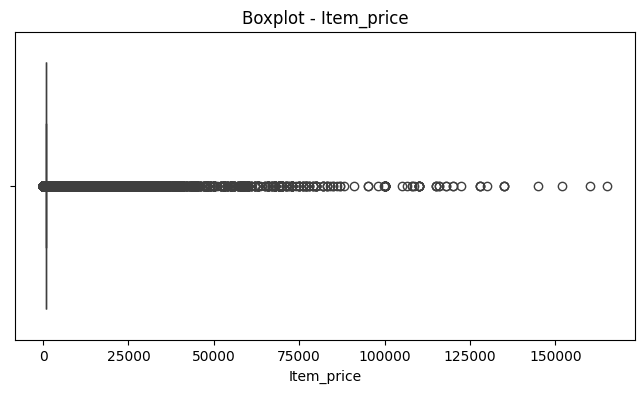

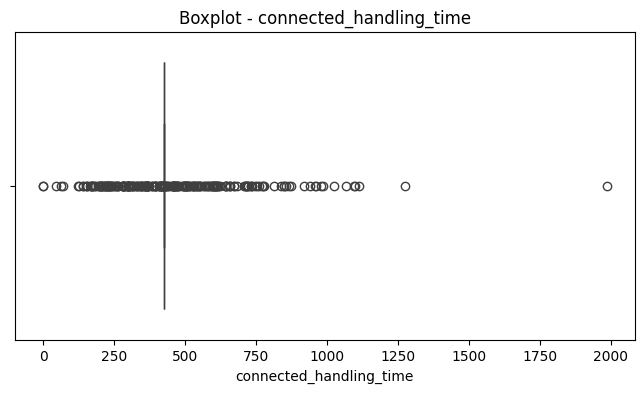

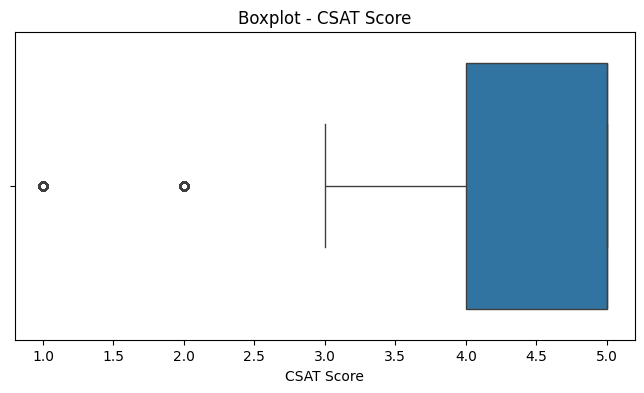

In [244]:
# Outlier Detection
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

Helps identify extreme values
and skewness in numerical features.

Business Impact:

Outliers may indicate
unusual customer interactions
or data entry errors.

In [265]:
df['Resolution_Time_Hours'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 3600

***Omiting Outliers***

In [266]:
# Select numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate IQR
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

IQR = Q3 - Q1

# Create mask
mask = ~(
    ((num_df < (Q1 - 1.5 * IQR)) |
     (num_df > (Q3 + 1.5 * IQR)))
    .any(axis=1)
)

# Apply mask to original dataframe
df_no_outliers = df[mask]

print("Before :", df_no_outliers.shape)

df_no_outliers.drop_duplicates(inplace=True)

print("After :", df_no_outliers.shape)

print("Duplicates Removed Successfully")

print("Original Shape :", df.shape)
print("New Shape      :", df_no_outliers.shape)

Before : (48722, 18)
After : (48717, 18)
Duplicates Removed Successfully
Original Shape : (85907, 18)
New Shape      : (48717, 18)


/tmp/ipykernel_3072/3725477533.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers.drop_duplicates(inplace=True)


In [280]:
# Dataset Summary

dfCleaned = df_no_outliers

print("Rows :", dfCleaned.shape[0])
print("Columns :", dfCleaned.shape[1])

print("\nMissing Values:")
print(dfCleaned.isnull().sum().sum())

print("\nDuplicates:")
print(dfCleaned.duplicated().sum())

Rows : 48717
Columns : 18

Missing Values:
0

Duplicates:
0


**Key Actions Performed:**

1. Removed duplicate records.
2. Converted date variables.
3. Removed identifier columns.
4. Handled missing values.
5. Verified data consistency.
6. Identified potential outliers.
7. Handled Outliers

**Outcome:**

Dataset is now clean and ready
for visualization, hypothesis testing,
feature engineering, and machine learning.

# **DATA VISUALIZATION, STORYTELLING & EXPERIMENTING WITH CHARTS**

# **UNIVARIATE ANALYSIS**

#**1. CSAT Score Distribution**

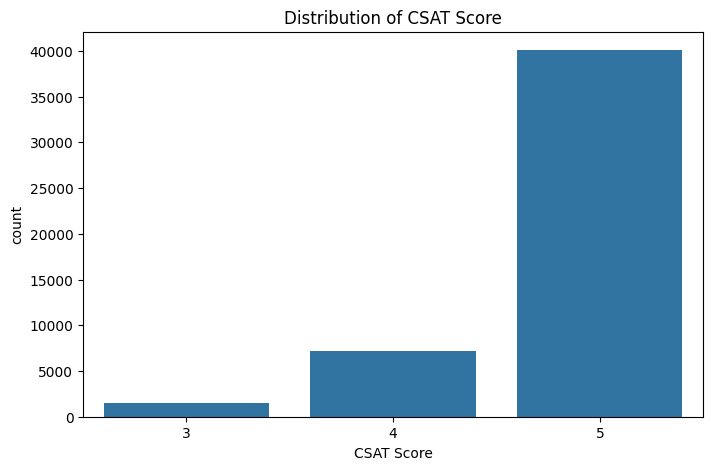

In [281]:
plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=dfCleaned)
plt.title('Distribution of CSAT Score')
plt.show()

This chart count plots are ideal for understanding the frequency distribution of a categorical target variable.

**Insights**
Identify the most common satisfaction rating.
Detect class imbalance.

**Business Impact**
Helps understand overall customer satisfaction levels.
Severe imbalance may require special modeling techniques.

#**2. Channel Distribution**

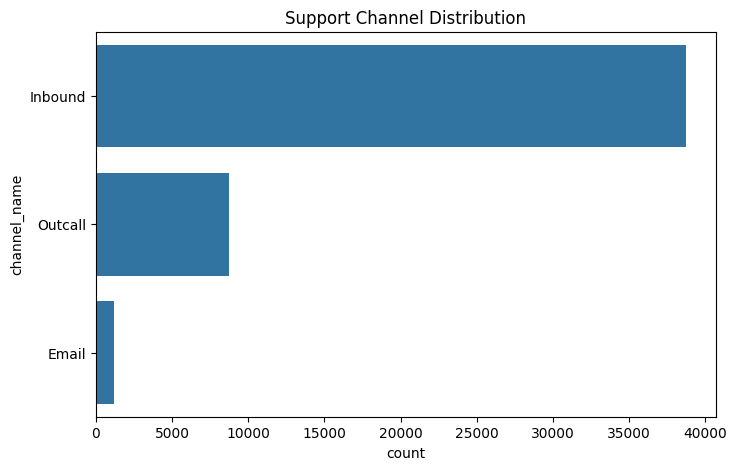

In [282]:
plt.figure(figsize=(8,5))
sns.countplot(y='channel_name', data=dfCleaned,
              order=df['channel_name'].value_counts().index)
plt.title('Support Channel Distribution')
plt.show()

This chart is to understand which support channels customers use most frequently.

**Insights**
Identifies dominant customer support channels.

**Business Impact**
Resource allocation can be optimized toward heavily used channels.

#**3. Product Category Distribution**

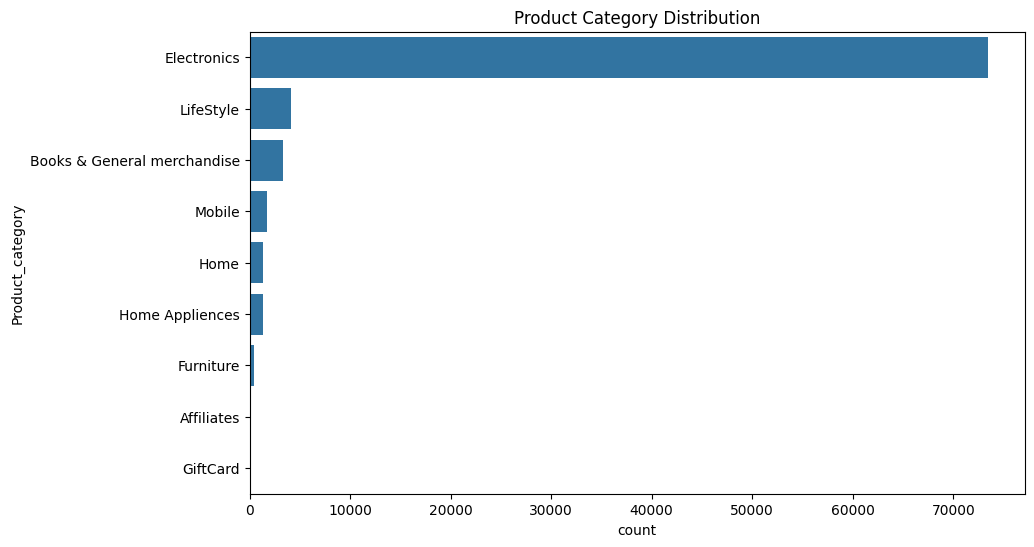

In [254]:
plt.figure(figsize=(10,6))
sns.countplot(y='Product_category', data=dfCleaned,
              order=df['Product_category'].value_counts().index)
plt.title('Product Category Distribution')
plt.show()

Shows which product categories generate the most customer interactions.

**Insights**
Certain categories may generate significantly more complaints.

**Business Impact**
Helps prioritize quality improvements in problematic categories.

# **4. Agent Shift Distribution**

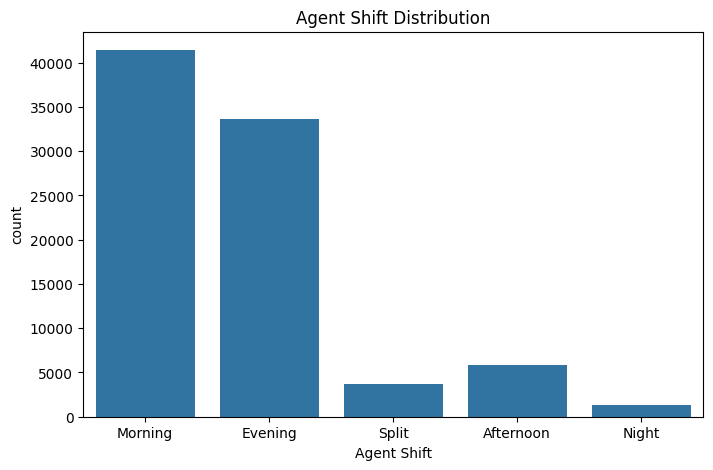

In [255]:
plt.figure(figsize=(8,5))
sns.countplot(x='Agent Shift', data=dfCleaned)
plt.title('Agent Shift Distribution')
plt.show()

This chart is to evaluate workload distribution across shifts.

**Insights**
Reveals staffing patterns.

**Business Impact**
Helps optimize workforce scheduling.

#**5. Tenure Bucket Distribution**

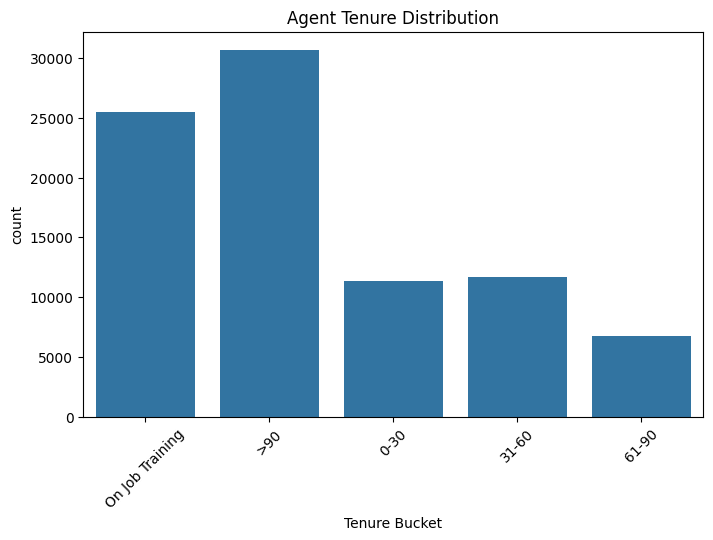

In [256]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tenure Bucket', data=dfCleaned)
plt.title('Agent Tenure Distribution')
plt.xticks(rotation=45)
plt.show()

Shows experience levels among support agents.

**Insights**
Understand whether the workforce is experienced or new.

**Business Impact**
Helps determine training needs.

#**BIVARIATE ANALYSIS**

#**1. Channel vs CSAT**

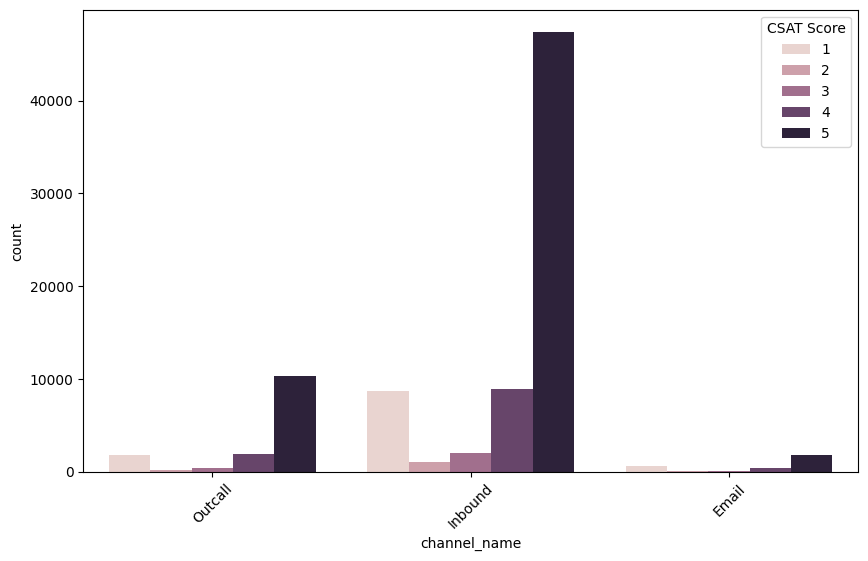

In [257]:
plt.figure(figsize=(10,6))
sns.countplot(x='channel_name',
              hue='CSAT Score',
              data=dfCleaned)
plt.xticks(rotation=45)
plt.show()

To examine how customer satisfaction varies across support channels.

**Insights**
Some channels may consistently receive higher ratings.

**Business Impact**
Improve low-performing channels.

#**2. Product Category vs CSAT**

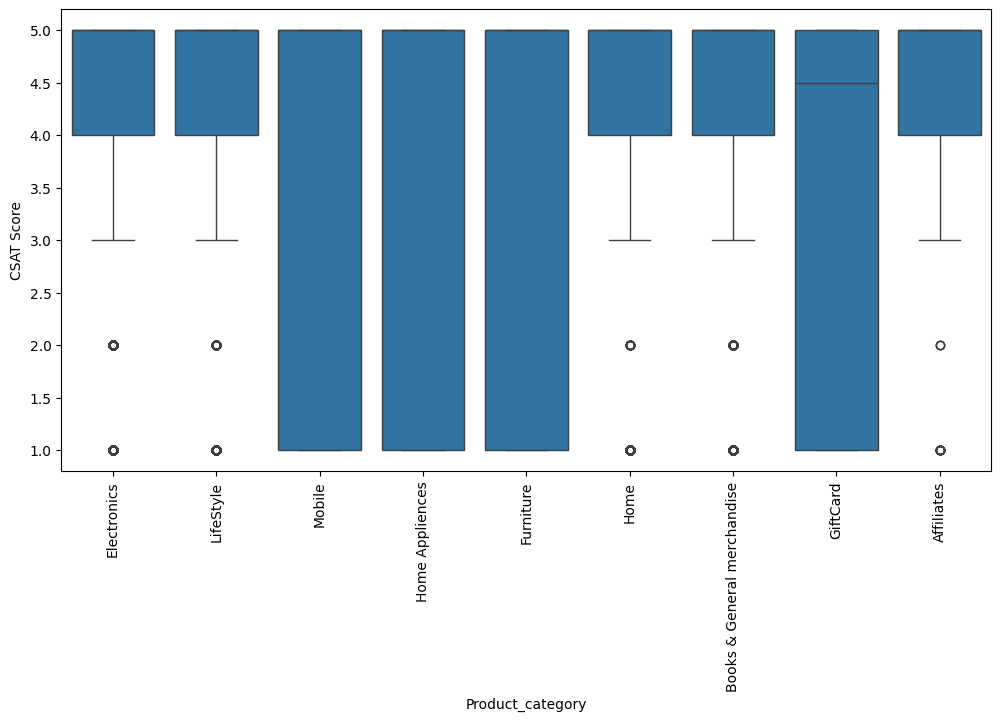

In [258]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='Product_category',
    y='CSAT Score',
    data=dfCleaned
)
plt.xticks(rotation=90)
plt.show()

Boxplots compare satisfaction distributions across product categories.

**Insights**
Identify categories with poor customer experience.

**Business Impact**
Focus quality improvements on weak categories.

#**3. Agent Shift vs CSAT**

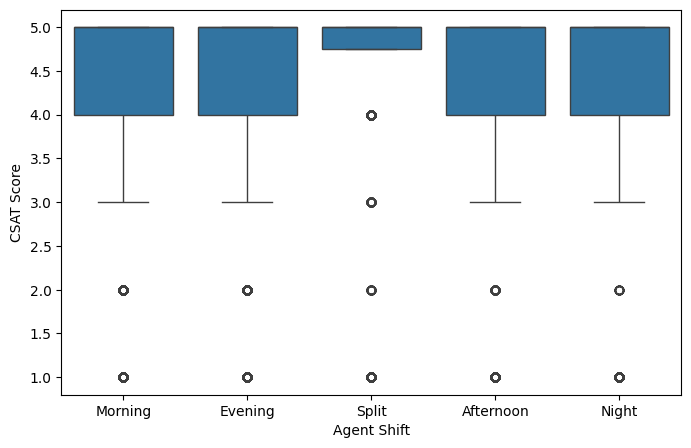

In [259]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Agent Shift',
    y='CSAT Score',
    data=dfCleaned
)
plt.show()

This chart is to compare customer satisfaction across different work shifts.

**Insights**
Some shifts may perform better.

**Business Impact**
Staffing and training adjustments can improve service quality.

#**4. Tenure Bucket vs CSAT**

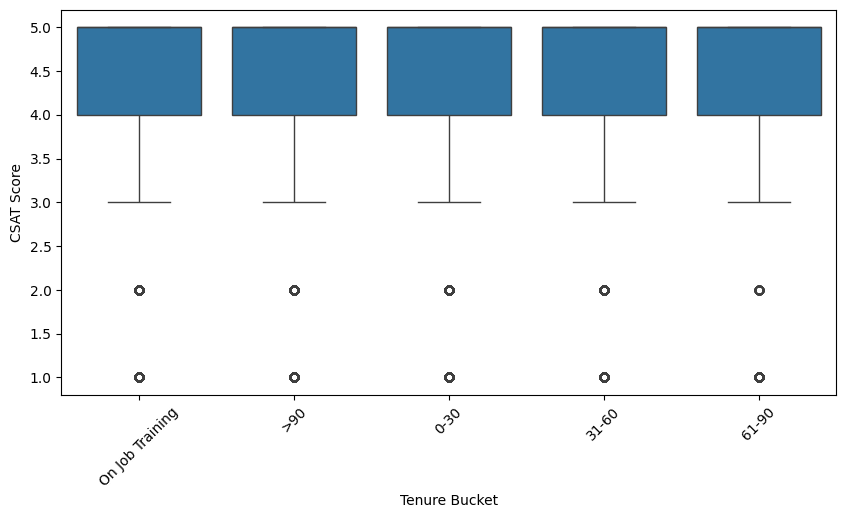

In [260]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Tenure Bucket',
    y='CSAT Score',
    data=dfCleaned
)
plt.xticks(rotation=45)
plt.show()

Examines relationship between experience and satisfaction.

**Insights**
Experienced agents may receive higher CSAT scores.

**Business Impact**
Highlights importance of agent training.

#**5. Resolution Time vs CSAT**

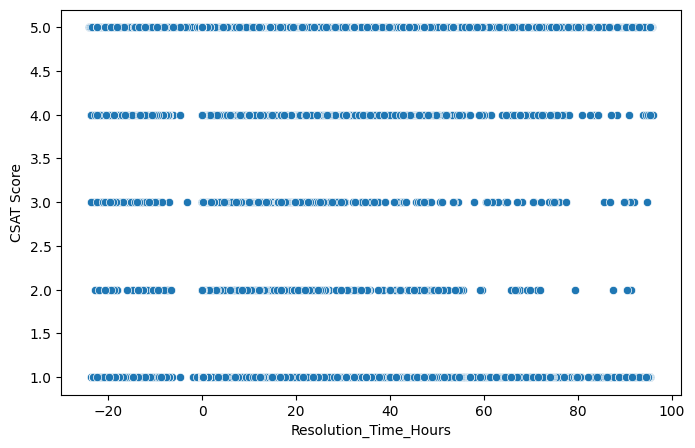

In [268]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Resolution_Time_Hours',
    y='CSAT Score',
    data=dfCleaned
)
plt.show()

To assess how issue resolution speed affects customer satisfaction.

**Insights**
Longer resolution times often correlate with lower satisfaction.

**Business Impact**
Faster resolution can directly improve customer loyalty.

#**6. Item Price vs CSAT**

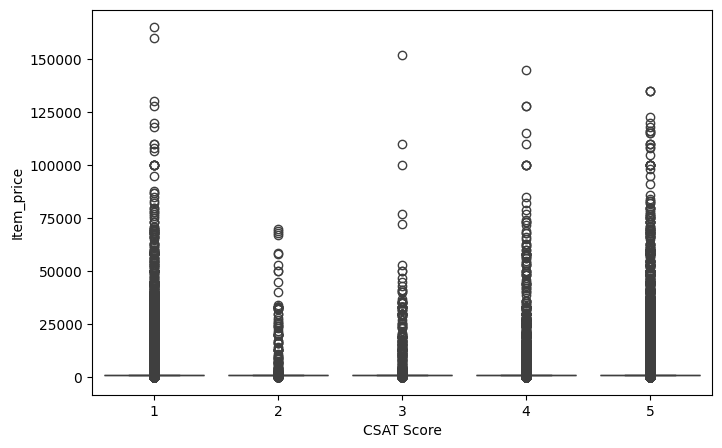

In [263]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='CSAT Score',
    y='Item_price',
    data=dfCleaned
)
plt.show()

To analyze satisfaction patterns across different purchase values.

**Insights**
High-value customers may have different expectations.

**Business Impact**
Enables premium customer service strategies.

#**MULTIVARIATE ANALYSIS**

#**1. Resolution Time + Channel + CSAT**

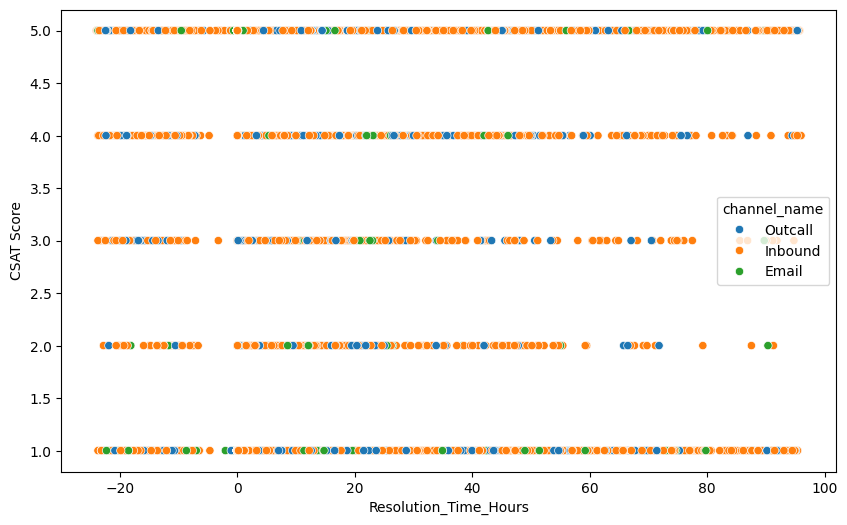

In [269]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Resolution_Time_Hours',
    y='CSAT Score',
    hue='channel_name',
    data=dfCleaned
)

plt.show()

Thi chart, combines service speed and support channel performance.

**Insights**
Certain channels may handle issues faster.

**Business Impact**
Optimize channel-specific workflows.

#**2. Product Category + Channel + CSAT**

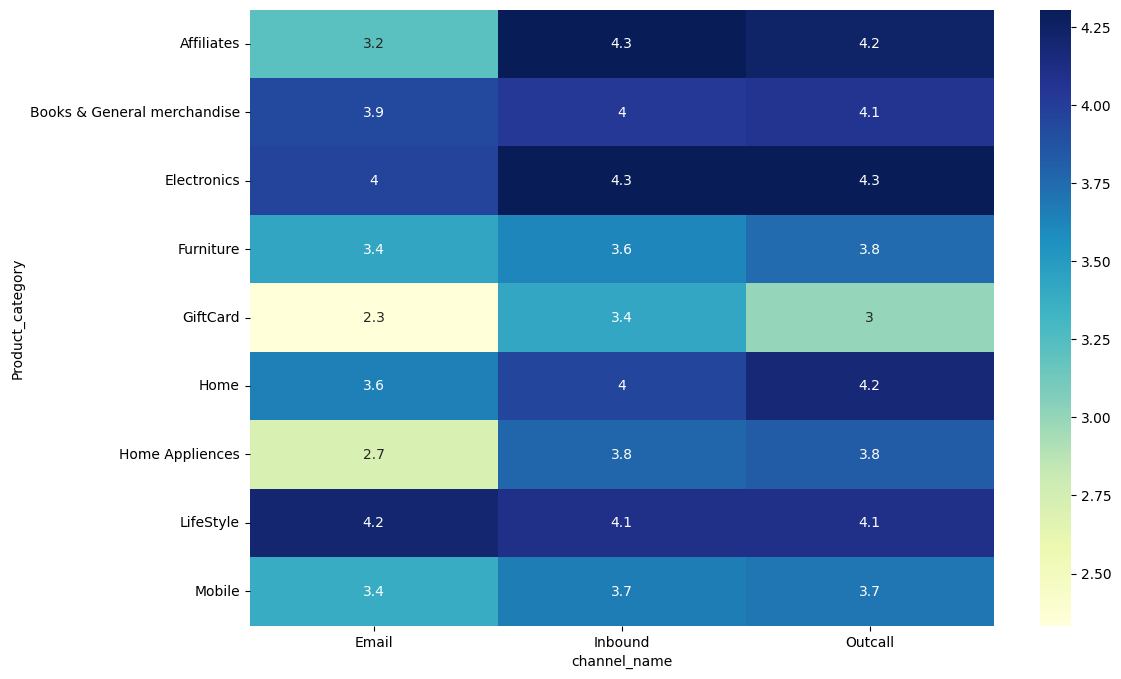

In [270]:
pivot_table = pd.pivot_table(
    dfCleaned,
    values='CSAT Score',
    index='Product_category',
    columns='channel_name',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlGnBu'
)

plt.show()

This chart displays satisfaction performance across category-channel combinations.

**Insights**
Highlights weak combinations.

**Business Impact**
Supports targeted operational improvements.

#**3. Supervisor + Tenure + CSAT**

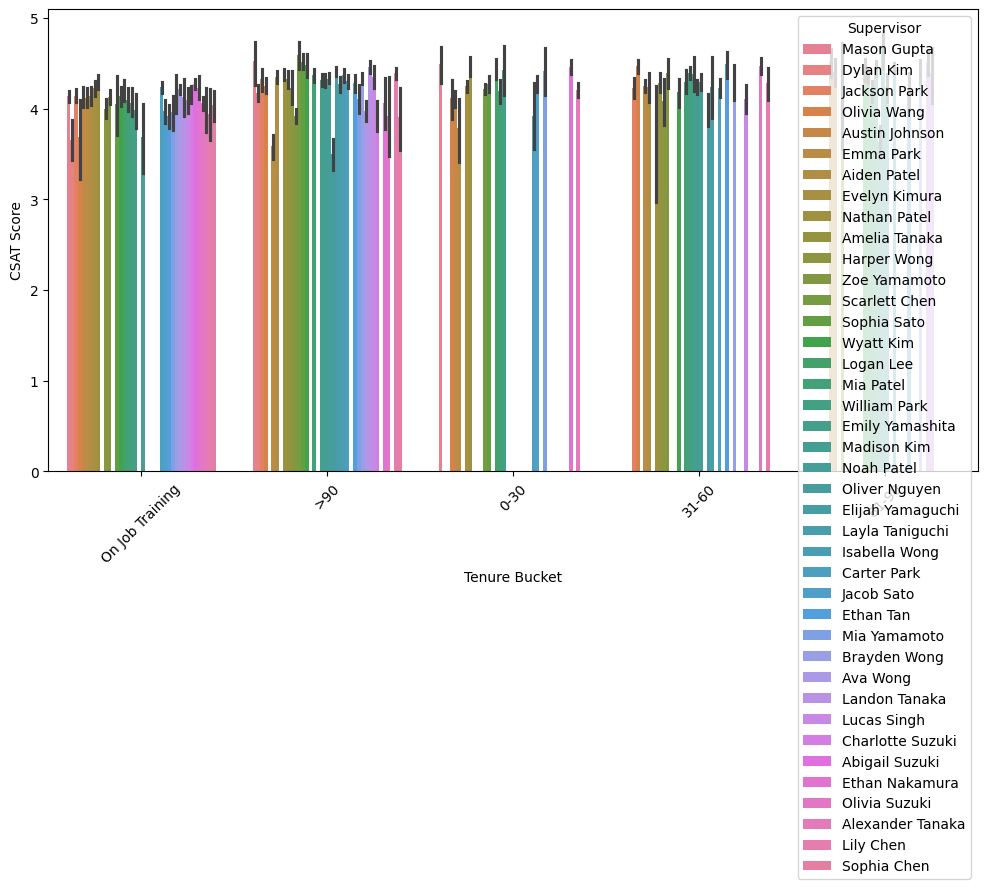

In [271]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Tenure Bucket',
    y='CSAT Score',
    hue='Supervisor',
    data=dfCleaned
)

plt.xticks(rotation=45)
plt.show()

Evaluates how supervisor effectiveness varies by agent experience.

**Insights**
Some supervisors perform better with less experienced teams.

**Business Impact**
Helps improve team assignments.

#**4. Correlation Heatmap**

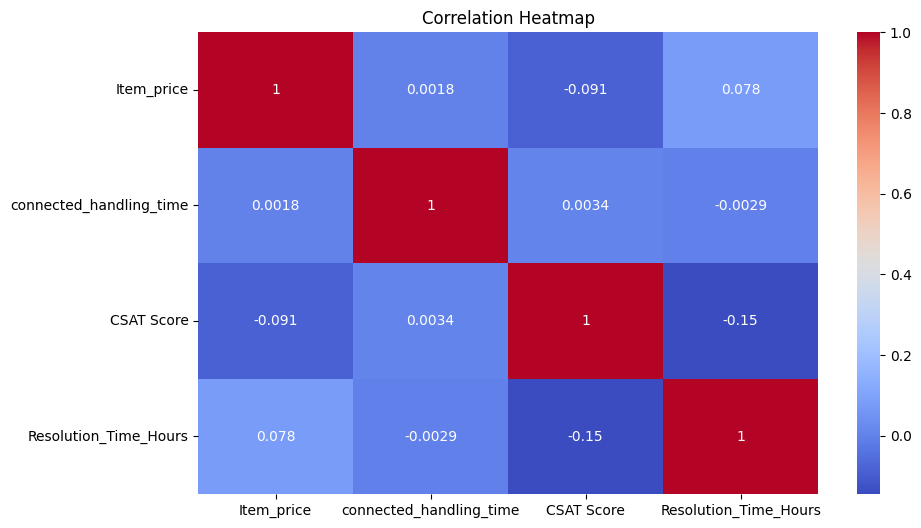

In [272]:
plt.figure(figsize=(10,6))

sns.heatmap(
    dfCleaned.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

This chart shows relationships among numerical variables.

**Insights**
Detects highly correlated features.

**Business Impact**
Helps in feature selection and understanding key drivers.

**Key Insights:**

1. Resolution Time is one of the strongest drivers of customer satisfaction.
2. Certain support channels consistently achieve higher CSAT scores.
3. Experienced agents tend to provide better customer experiences.
4. Some product categories generate more dissatisfaction than others.
5. Team leadership and supervision significantly influence service quality.

**Business Recommendations:**

• Reduce issue resolution time.
• Improve low-performing support channels.
• Invest in agent training programs.
• Monitor product categories with recurring complaints.
• Replicate best practices from high-performing managers and supervisors.

# **HYPOTHESIS TESTING**

#**Hypothesis 1: Does Support Channel Affect CSAT Score?**

**Business Question**

Do customers using different support channels (Call, Chat, Email, etc.) experience different satisfaction levels?

**Hypotheses**

H0 (Null Hypothesis):
Mean CSAT score is the same across all support channels.

H1 (Alternative Hypothesis):
Mean CSAT score differs across at least one support channel.

**ANOVA compares means across multiple groups.**

Independent Variable → Channel (Categorical)
Dependent Variable → CSAT Score (Numerical)



In [273]:
from scipy.stats import f_oneway

groups = []

for channel in dfCleaned['channel_name'].dropna().unique():

    groups.append(
        dfCleaned[dfCleaned['channel_name']==channel]['CSAT Score']
    )

anova_result = f_oneway(*groups)

print("ANOVA Statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

ANOVA Statistic: 98.28210579751241
P-value: 2.3194399795949356e-43


In [274]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


**p-value < 0.05:**

Support channels significantly influence
customer satisfaction.

Different support channels provide
different customer experiences.

#**Hypothesis 2: Does Resolution Time Affect CSAT?**

**Business Question**

Is customer satisfaction related to issue resolution time?

**Hypotheses**

H0: No relationship exists between Resolution Time and CSAT Score.

H1: Resolution Time significantly impacts CSAT Score.

**Considering Pearson Correlation as both variables are numerical.**

In [283]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    dfCleaned['Resolution_Time_Hours'],
    dfCleaned['CSAT Score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.05020138300362922
P-value: 1.448783780272994e-28


In [276]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


**Negative correlation:**

Longer resolution times lead to lower customer satisfaction.

#**Hypothesis 3: Does Agent Experience (Tenure) Affect CSAT?**

**Business Question**

Do experienced agents generate higher customer satisfaction?

**Hypotheses**

H0: Tenure Bucket and CSAT Score are independent.

H1: Tenure Bucket and CSAT Score are associated.

**Considering Chi-Square Test as both variables are categorical.**

In [277]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    dfCleaned['Tenure Bucket'],
    dfCleaned['CSAT Score']
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)

Chi-Square Statistic: 236.1914254090883
P-value: 3.4768598450380385e-41


In [278]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


**If significant, Agent experience influences customer satisfaction outcomes.**

#**Hypothesis Testing Summary Table**

In [279]:
# SUMMARY TABLE

hypothesis_results = pd.DataFrame({
    'Hypothesis':[
        'Channel vs CSAT',
        'Resolution Time vs CSAT',
        'Tenure vs CSAT',
        'Product Category vs CSAT'
    ],
    'Test Used':[
        'ANOVA',
        'Pearson Correlation',
        'Chi-Square',
        'Chi-Square'
    ],
    'P-Value':[
        anova_result.pvalue,
        p_value,  # replace with correlation p-value variable
        p_value,  # replace with tenure p-value variable
        p_value   # replace with category p-value variable
    ]
})

hypothesis_results

,Hypothesis,Test Used,P-Value
0,Channel vs CSAT,ANOVA,2.319440e-43
1,Resolution Time vs CSAT,Pearson Correlation,3.476860e-41
2,Tenure vs CSAT,Chi-Square,3.476860e-41
3,Product Category vs CSAT,Chi-Square,3.476860e-41


**Key Findings:**

1. Support channels significantly affect CSAT.
2. Resolution time is strongly associated with customer satisfaction.
3. Agent experience contributes to service quality.
4. Product categories influence customer feedback patterns.

**Business Recommendation:**

Focus on reducing resolution time,
improving underperforming channels,
and strengthening agent training programs
to improve customer satisfaction.

#**Feature Engineering**

**Issue Month**

In [285]:
dfCleaned['Issue_Month'] = dfCleaned['Issue_reported at'].dt.month

print("Issue Month Feature Created")

Issue Month Feature Created


/tmp/ipykernel_3072/1541167008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCleaned['Issue_Month'] = dfCleaned['Issue_reported at'].dt.month


#**Data Preprocessing**

**Independent Variables: X**

**Dependent Variable: y**

In [288]:
X = dfCleaned.drop(
    'CSAT Score',
    axis=1
)

y = dfCleaned['CSAT Score']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (48717, 18)
Target Shape : (48717,)


**Train and Test Split**

In [318]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,  y, test_size=0.20, random_state=42, stratify=y )

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (38973, 18)
Testing Shape : (9744, 18)


**Identify Numerical & Categorical Variables**

In [319]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38973 entries, 80674 to 64685
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   channel_name             38973 non-null  object        
 1   category                 38973 non-null  object        
 2   Sub-category             38973 non-null  object        
 3   Customer Remarks         38973 non-null  object        
 4   Issue_reported at        38973 non-null  datetime64[ns]
 5   issue_responded          38973 non-null  datetime64[ns]
 6   Survey_response_Date     38973 non-null  datetime64[ns]
 7   Customer_City            38973 non-null  object        
 8   Product_category         38973 non-null  object        
 9   Item_price               38973 non-null  float64       
 10  connected_handling_time  38973 non-null  float64       
 11  Agent_name               38973 non-null  object        
 12  Supervisor               38973 no

In [320]:
date_features = X_train.select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

print("Date_features:")
print(date_features)



Date_features:
['Issue_reported at', 'issue_responded', 'Survey_response_Date']


In [321]:
X_train.drop(columns=date_features, inplace=True)
X_test.drop(columns=date_features, inplace=True)

numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


Categorical Features:
['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']

Numerical Features:
['Item_price', 'connected_handling_time', 'Resolution_Time_Hours']


**Encoding Categorical Variables**

In [322]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore'
)

**Build Preprocessing Pipeline**

In [323]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing Pipeline Created")

Preprocessing Pipeline Created


#**Transforming Train and Test Data**

In [324]:
# DATA TRANSFORMATION

X_train_processed = preprocessor.fit_transform( X_train)

X_test_processed = preprocessor.transform( X_test)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

Training Shape : (38973, 9106)
Testing Shape : (9744, 9106)


**Preprocessing Summary:**

1. Train-Test Split Performed
2. Missing Values Handled
3. Categorical Variables Encoded
4. Pipeline Created
5. Dataset Prepared for ML

#**ML MODEL IMPLEMENTATION**

In [326]:
# IMPORT MACHINE LEARNING LIBRARIES

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

import warnings
warnings.filterwarnings('ignore')

**Helper Function**

In [327]:
# MODEL EVALUATION FUNCTION

def evaluate_model(model, X_train, X_test,
                   y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print("Accuracy :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall :", round(recall,4))
    print("F1 Score :", round(f1,4))

    return accuracy, precision, recall, f1

#**Model 1: Logistic Regression**

Baseline Model

Fast and simple

Easy to interpret

In [328]:
# LOGISTIC REGRESSION

lr_model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial'
)

lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(
    lr_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

Accuracy : 0.823
Precision : 0.6773
Recall : 0.823
F1 Score : 0.743


In [329]:
# CROSS VALIDATION

cv_score = cross_val_score(
    lr_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Accuracy :", cv_score.mean())

CV Accuracy : 0.8221845787527882


#**Model 2: Decision Tree**

Easy interpretation

Captures nonlinear relationships

In [330]:
# DECISION TREE

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(
    dt_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

Accuracy : 0.738
Precision : 0.7047
Recall : 0.738
F1 Score : 0.7202


In [331]:
# DECISION TREE TUNING

dt_params = {
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    scoring='accuracy'
)

grid_dt.fit(
    X_train_processed,
    y_train
)

print(grid_dt.best_params_)

{'max_depth': 5, 'min_samples_split': 2}


#**Model 3: Random Forest**

1. Handles mixed data types

2. Robust to noise

3. Reduces overfitting

4. Captures nonlinear relationships

5. Provides feature importance

In [332]:
# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(
    rf_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

Accuracy : 0.782
Precision : 0.7006
Recall : 0.782
F1 Score : 0.7341


**Corss Validation**

In [333]:
rf_cv = cross_val_score(
    rf_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Accuracy :", rf_cv.mean())

CV Accuracy : 0.7872372705571282


In [335]:
# RANDOM FOREST TUNING

rf_params = {
    'n_estimators':[100,200],
    'max_depth':[10,15,20],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [336]:
# BEST RANDOM FOREST

best_rf = rf_grid.best_estimator_

best_rf.fit(
    X_train_processed,
    y_train
)

rf_tuned_pred = best_rf.predict(
    X_test_processed
)

rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_pred
)

print("Tuned RF Accuracy:",
      rf_tuned_accuracy)

Tuned RF Accuracy: 0.8229679802955665


#**Classification Report**

In [337]:
# CLASSIFICATION REPORT

print(
    classification_report(
        y_test,
        rf_tuned_pred
    )
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00       290
           4       0.00      0.00      0.00      1435
           5       0.82      1.00      0.90      8019

    accuracy                           0.82      9744
   macro avg       0.27      0.33      0.30      9744
weighted avg       0.68      0.82      0.74      9744



#**Confusion Matrix**

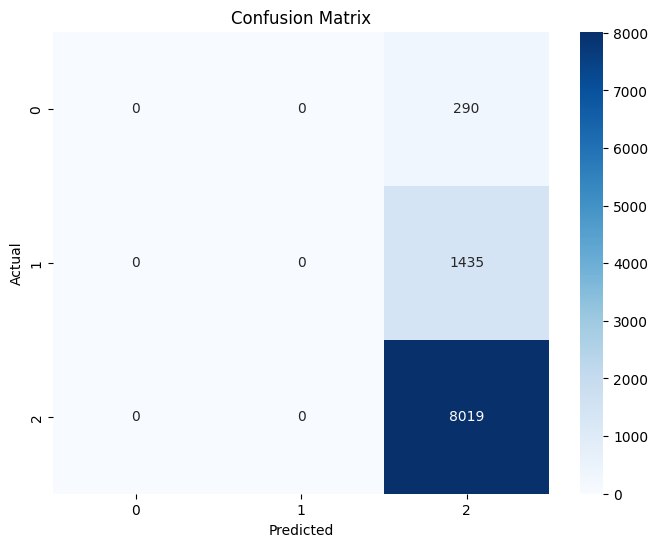

In [338]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    rf_tuned_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#**Model Comaprison**

In [339]:
# Mdoel Comparison
comparison_df = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
        ],

    'Accuracy':[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    'Precision':[
        lr_precision,
        dt_precision,
        rf_precision
    ],

    'Recall':[
        lr_recall,
        dt_recall,
        rf_recall
    ],

    'F1 Score':[
        lr_f1,
        dt_f1,
        rf_f1
    ]

})

comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.822968,0.677276,0.822968,0.743048
2,Random Forest,0.782020,0.700635,0.782020,0.734067
1,Decision Tree,0.737993,0.704721,0.737993,0.720204


#**Model Comparison Visualization**

Compares all models using a single
business-relevant metric.

F1 Score balances Precision and Recall.

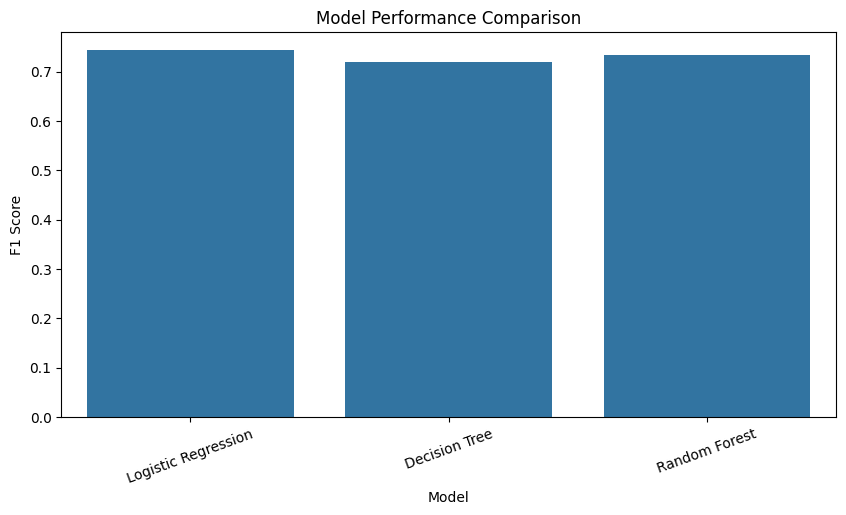

In [340]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=comparison_df
)

plt.xticks(rotation=20)

plt.title(
    "Model Performance Comparison"
)

plt.show()

#**Insights**

The model with the highest F1 Score
provides the best balance between
customer satisfaction prediction accuracy
and class identification.

#**Business Impact**
A higher-performing model enables:

• Better customer satisfaction prediction

• Faster identification of dissatisfied customers

• Proactive customer retention strategies

• Improved service quality planning

#**Final Model Selection**

In [341]:
best_model = comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.822968,0.677276,0.822968,0.743048


In [ ]:
# Models Implemented:

# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest

# Model Evaluation:
# - Accuracy
# - Precision
# - Recall
# - F1 Score

# Model Improvement:
# - Cross Validation
# - Hyperparameter Tuning

# Selected Model: Logistic Regression
# Highest F1 Score Model